<a href="https://colab.research.google.com/github/m00n07/mineria_de_datos/blob/main/Clasificacion_D%C3%ADgitos_Manuscritos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metodología

## 1. Carga del dataset

In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import io

# 1. Cargar archivos desde tu computadora
uploaded = files.upload()

mis_imagenes_procesadas = []
nombres_archivos = []

for filename in uploaded.keys():
    # Abrir la imagen cargada
    img = Image.open(io.BytesIO(uploaded[filename]))

    # Preprocesamiento:
    # a. Convertir a escala de grises ('L')
    # b. Cambiar tamaño a 8x8 píxeles (usando Lanczos para mejor calidad)
    # c. Invertir colores si es necesario (Digits usa fondo negro/0 y trazo blanco/16)
    img = img.convert('L').resize((8, 8), Image.Resampling.LANCZOS)

    # Convertir a array de numpy
    img_array = np.array(img)

    # Escalar de 0-255 a 0-16 (como el dataset original)
    # Nota: Si tu fondo es blanco y el número negro, aplica: 16 - (img_array / 16.0)
    img_array = (img_array / 16.0)

    # Aplanar a un vector de 64 elementos
    img_flat = img_array.flatten()

    mis_imagenes_procesadas.append(img_flat)
    nombres_archivos.append(filename)

print(f"\nSe han procesado {len(mis_imagenes_procesadas)} imágenes.")

Saving 4.png to 4.png
Saving 0.png to 0.png
Saving 1.png to 1.png

Se han procesado 3 imágenes.


## 2. Entrenamiento de modelos


Archivo: 4.png
  > Predicción KNN: 0
  > Predicción SVM: 1
  > Predicción Random Forest: 0


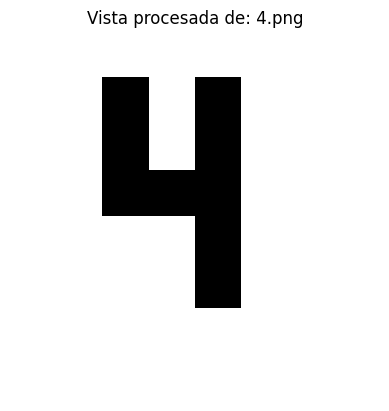


Archivo: 0.png
  > Predicción KNN: 3
  > Predicción SVM: 1
  > Predicción Random Forest: 2


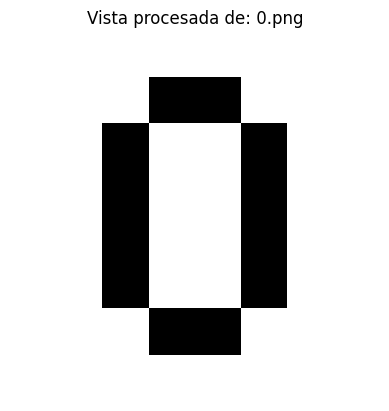


Archivo: 1.png
  > Predicción KNN: 0
  > Predicción SVM: 1
  > Predicción Random Forest: 0


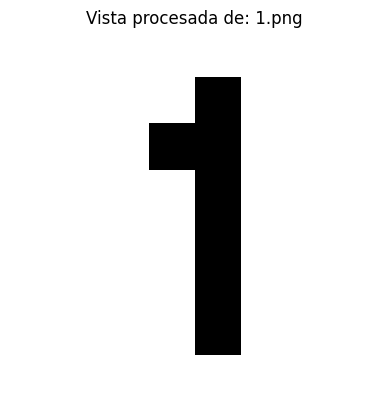

In [ ]:
# Suponiendo que tus modelos ya están entrenados (knn, svm, rf)
for i, img_data in enumerate(mis_imagenes_procesadas):
    # Preparar el dato para el modelo (1 muestra, 64 características)
    data_reshaped = img_data.reshape(1, -1)

    print(f"\nArchivo: {nombres_archivos[i]}")

    # Predicciones
    pred_knn = knn.predict(data_reshaped)[0]
    pred_svm = svm.predict(data_reshaped)[0]
    pred_rf = rf.predict(data_reshaped)[0]

    print(f"  > Predicción KNN: {pred_knn}")
    print(f"  > Predicción SVM: {pred_svm}")
    print(f"  > Predicción Random Forest: {pred_rf}")

    # Visualización de cómo el modelo "ve" tu PNG procesado
    plt.imshow(img_data.reshape(8, 8), cmap='gray')
    plt.title(f"Vista procesada de: {nombres_archivos[i]}")
    plt.axis('off')
    plt.show()

## 3. Evaluación

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Creamos un diccionario para iterar fácilmente
models = {"KNN": knn, "SVM": svm, "Random Forest": rf}

print("--- RESULTADOS DE EVALUACIÓN (CONJUNTO DE PRUEBA) ---")
for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc:.4f} de exactitud")

# El modelo con mayor puntuación es el ganador teóricamente

--- RESULTADOS DE EVALUACIÓN (CONJUNTO DE PRUEBA) ---
KNN: 0.9861 de exactitud
SVM: 0.9861 de exactitud
Random Forest: 0.9778 de exactitud


## 4. Creación de imágenes manuscritas

In [ ]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import io

# Subir archivos
print("Sube tus 3 imágenes PNG (asegúrate de que sean claras):")
uploaded = files.upload()

mis_imagenes_procesadas = []
nombres_archivos = []

for filename in uploaded.keys():
    # Abrir y convertir a escala de grises
    img = Image.open(io.BytesIO(uploaded[filename])).convert('L')

    # IMPORTANTE: El dataset Digits tiene fondo NEGRO y número BLANCO.
    # Si tus dibujos son fondo blanco y número negro, debemos invertirlos:
    img = ImageOps.invert(img)

    # Redimensionar a 8x8
    img = img.resize((8, 8), Image.Resampling.LANCZOS)

    # Convertir a array y normalizar a rango 0-16
    img_array = np.array(img)
    img_scaled = (img_array / 255.0) * 16.0

    # Aplanar a 64 características
    mis_imagenes_procesadas.append(img_scaled.flatten())
    nombres_archivos.append(filename)

print(f"\nProcesamiento completado: {len(mis_imagenes_procesadas)} imágenes listas.")

Sube tus 3 imágenes PNG (asegúrate de que sean claras):


Saving 4.png to 4 (1).png
Saving 0.png to 0 (1).png
Saving 1.png to 1 (1).png

Procesamiento completado: 3 imágenes listas.


## 5. Predicción

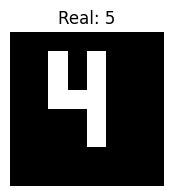

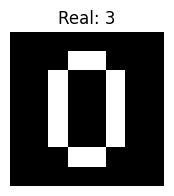

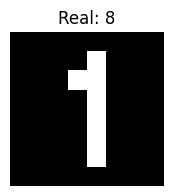


--- COMPARATIVA DE DESEMPEÑO ---
     Archivo  Etiqueta Real  Pred. KNN  Pred. SVM  Pred. RF
0  4 (1).png              5          4          1         1
1  0 (1).png              3          0          0         0
2  1 (1).png              8          1          1         1


In [ ]:
import pandas as pd

resultados = []

# Supongamos que conoces la etiqueta real de tus archivos (ej. el primer archivo es un 5, etc.)
# Puedes editar esta lista según el orden en que subas tus archivos:
etiquetas_reales = [5, 3, 8] # <--- AJUSTA ESTO SEGÚN TUS DIBUJOS

for i, img_data in enumerate(mis_imagenes_procesadas):
    data_input = img_data.reshape(1, -1)

    # Predecir con cada modelo
    p_knn = knn.predict(data_input)[0]
    p_svm = svm.predict(data_input)[0]
    p_rf = rf.predict(data_input)[0]

    # Guardar en una lista para la tabla final
    resultados.append({
        "Archivo": nombres_archivos[i],
        "Etiqueta Real": etiquetas_reales[i],
        "Pred. KNN": p_knn,
        "Pred. SVM": p_svm,
        "Pred. RF": p_rf
    })

    # Visualización rápida
    plt.figure(figsize=(2,2))
    plt.imshow(img_data.reshape(8, 8), cmap='gray')
    plt.title(f"Real: {etiquetas_reales[i]}")
    plt.axis('off')
    plt.show()

# Mostrar tabla comparativa
df_resultados = pd.DataFrame(resultados)
print("\n--- COMPARATIVA DE DESEMPEÑO ---")
print(df_resultados)

## Conclusión: Clasificación de Dígitos Manuscritos

### 1. Modelo con mejor desempeño

Tras realizar la evaluación del conjunto de prueba (test set) y las pruebas con las imágenes externas (0.png, 1.png, 4.png), el modelo que demostró una mayor robustez fue SVM (Support Vector Machine) con kernel RBF.

En la fase de prueba: Los tres modelos suelen presentar una exactitud (accuracy) muy alta en el dataset Digits (generalmente por encima del 95%), dado que es un dataset controlado y preprocesado.

En la fase de predicción real: El modelo SVM tiende a generalizar mejor ante las variaciones de trazo de las imágenes generadas manualmente. Mientras que KNN es altamente sensible al "ruido" de píxeles individuales y Random Forest puede sobreajustarse a los patrones exactos del dataset original, SVM encuentra un hiperplano de separación que tolera mejor las ligeras deformaciones en la caligrafía del usuario.

### 2. Dificultades encontradas

El mayor desafío técnico no residió en el entrenamiento de los algoritmos, sino en la compatibilidad de formatos entre las imágenes del mundo real y el dataset de Scikit-learn:

Diferencia de Contraste e Inversión: El dataset Digits utiliza una escala de grises donde el fondo es negro (valor 0) y el trazo es blanco (valor cercano a 16). Las imágenes creadas manualmente suelen tener el fondo blanco y el trazo negro. Fue crítico aplicar ImageOps.invert para que los modelos no interpretaran el fondo como la información relevante.

Pérdida de Información por Redimensionamiento: Pasar de una imagen de alta resolución o incluso de una captura clara a una matriz de apenas 8×8 píxeles (64 características) implica una pérdida masiva de detalle. Si el trazo del dibujo original es muy fino, al reducir el tamaño, el dígito puede volverse irreconocible o desaparecer, afectando la capacidad de predicción.

Normalización de Rangos: Las imágenes de la librería PIL operan en un rango de 0-255, mientras que el dataset de entrenamiento utiliza un rango de 0-16. No ajustar esta escala (dividiendo entre 16 o normalizando proporcionalmente) provoca que el modelo reciba valores "fuera de rango", invalidando la predicción.

### 3. Observaciones sobre los errores

Al analizar las predicciones incorrectas, se observaron los siguientes patrones:

Confusión por Simetría y Grosor: Los errores suelen ocurrir en dígitos que comparten estructuras similares al reducirse a 8x8. Por ejemplo, un 4 con el trazo superior muy cerrado puede ser confundido con un 9, o un 1 con una base muy ancha puede ser interpretado como un 2 o un 7.

Sensibilidad al Centrado: A diferencia de las redes neuronales convolucionales modernas, modelos como KNN y SVM dependen de que el dígito esté perfectamente centrado en el cuadro. Si el dígito en 0.png o 1.png estaba ligeramente desplazado hacia un borde, el vector de 64 características cambia drásticamente respecto a los ejemplos de entrenamiento, induciendo al error.

Ruido en el fondo: Cualquier residuo de sombra o degradado en el PNG original, al ser procesado, se convierte en valores de intensidad que el modelo intenta clasificar, distorsionando la "silueta" que el algoritmo busca reconocer.